<a href="https://colab.research.google.com/github/rafaga/ejercicios_mia/blob/main/06_vision_computacional/ejercicio_1/13%20YOLO%20ultralytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tutorial original en ultralytics

https://colab.research.google.com/github/ultralytics/ultralytics/blob/main/examples/tutorial.ipynb#scrollTo=bpF9-vS_DAaf


App para anotar/etiquetar imágenes de nuestra propia base de datos:

https://app.roboflow.com/login

In [6]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.148 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.5/112.6 GB disk)


In [7]:
import os
from google.colab import files

# Cambia esto por el nombre o ruta esperada de tu imagen
image_path = "zhen-yao-unsplash.jpg"

if not os.path.exists(image_path):
    print(f"No se encontró '{image_path}'. Sube la imagen desde tu sistema local...")
    uploaded = files.upload()  # Abre el selector de archivos del sistema local

    # Toma el primer archivo subido y lo renombra a image_path si el nombre no coincide
    uploaded_filename = list(uploaded.keys())[0]
    if uploaded_filename != image_path:
        os.rename(uploaded_filename, image_path)

    print(f"Imagen guardada como '{image_path}'.")
else:
    print(f"'{image_path}' ya existe, no es necesario subirla de nuevo.")

'zhen-yao-unsplash.jpg' ya existe, no es necesario subirla de nuevo.


# 1. Predict

YOLOv8 may be used directly in the Command Line Interface (CLI) with a `yolo` command for a variety of tasks and modes and accepts additional arguments, i.e. `imgsz=640`. See a full list of available `yolo` [arguments](https://docs.ultralytics.com/usage/cfg/) and other details in the [YOLOv8 Predict Docs](https://docs.ultralytics.com/modes/train/).

In [8]:
# Run inference on an image with YOLOv8n
!yolo predict model=yolov8n.pt source='zhen-yao-unsplash.jpg'

Ultralytics 8.4.148 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

image 1/1 /content/zhen-yao-unsplash.jpg: 448x640 1 person, 4 cars, 1 bus, 1 truck, 1 traffic light, 6.5ms
Speed: 30.4ms preprocess, 6.5ms inference, 18.0ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict-4
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [9]:
# Run inference on an image with YOLOv8n
!yolo predict model=yolov8n.pt source='https://ultralytics.com/images/zidane.jpg'

Ultralytics 8.4.148 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

Found https://ultralytics.com/images/zidane.jpg locally at zidane.jpg
image 1/1 /content/zidane.jpg: 384x640 2 persons, 1 tie, 6.3ms
Speed: 30.8ms preprocess, 6.3ms inference, 16.9ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict-5
💡 Learn more at https://docs.ultralytics.com/modes/predict


## 1. Detection

YOLOv8 _detection_ models have no suffix and are the default YOLOv8 models, i.e. `yolov8n.pt` and are pretrained on COCO. See [Detection Docs](https://docs.ultralytics.com/tasks/detect/) for full details.

Ultralytics 8.4.148 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=None, opset=None, optimize=False, optimizer=

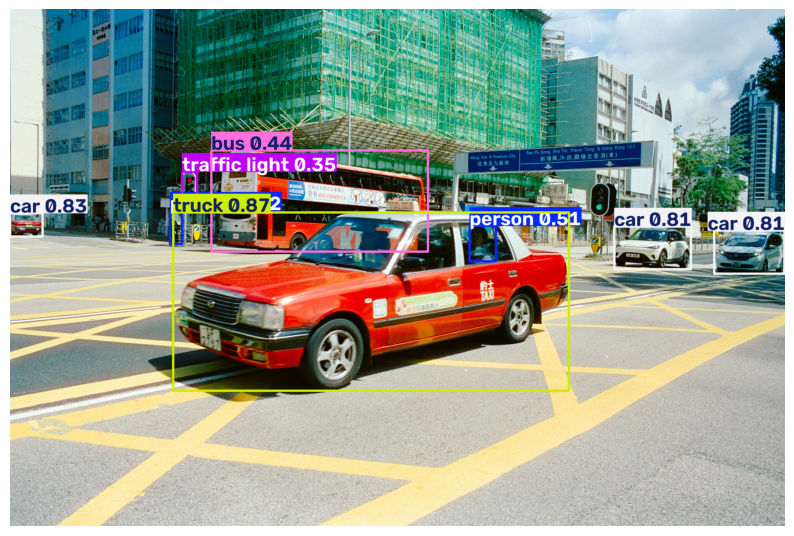

In [10]:
# Load YOLOv8n, train it on COCO128 for 3 epochs and predict an image with it
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

model = YOLO('yolov8n.pt')  # load a pretrained YOLOv8n detection model
model.train(data='coco128.yaml', epochs=3)  # train the model
results = model('zhen-yao-unsplash.jpg', save=True)  # predict on an image

# results es una lista (una entrada por imagen procesada)
for r in results:
    im_array = r.plot()  # devuelve un array BGR con las cajas dibujadas
    im_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)  # matplotlib espera RGB

    plt.figure(figsize=(10, 10))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.show()

Ultralytics 8.4.148 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=None, opset=None, optimize=False, optimizer=

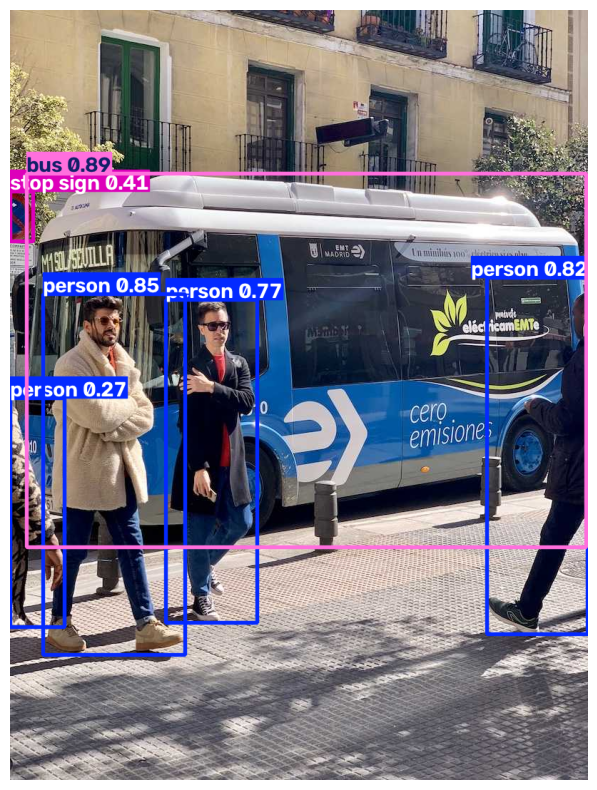

In [11]:
# Load YOLOv8n, train it on COCO128 for 3 epochs and predict an image with it
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

model = YOLO('yolov8n.pt')  # load a pretrained YOLOv8n detection model
model.train(data='coco128.yaml', epochs=3)  # train the model
results = model('https://ultralytics.com/images/bus.jpg', save=True)  # predict on an image

# results es una lista (una entrada por imagen procesada)
for r in results:
    im_array = r.plot()  # devuelve un array BGR con las cajas dibujadas
    im_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)  # matplotlib espera RGB

    plt.figure(figsize=(10, 10))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.show()